# 01_narrative_theory_eda.ipynb
Exploratory Data Analysis for Propp and Vogler theories.

In [12]:
from google.colab import drive
drive.mount("/content/drive")

ROOT_PAHT = "/content/drive/MyDrive/projects/DLThon2"
#ROOT_PAHT = ".."

os.chdir(ROOT_PAHT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/projects/DLThon2


In [13]:
import os
import sys
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

sys.path.append('ROOT_PAHT')
import src.data_loader

### 1. 데이터 로드
`data_loader`를 사용하여 `theory.json` 데이터를 불러옵니다.

In [ ]:
theory_data = data_loader.load_theory()
print("Theory Data Keys:", theory_data.keys())

Theory Data Keys: dict_keys(['propp_functions', 'vogler_stages'])


### 2. 프롭의 31가지 기능 (Propp's Functions) 분석
블라디미르 프롭의 민담 형태론에 기초한 기능 리스트를 데이터프레임으로 확인합니다.

In [ ]:
propp_df = pd.DataFrame(theory_data['propp_functions'])
print(f"Total Propp Functions found: {len(propp_df)}")
propp_df.head()

Total Propp Functions found: 5


,id,symbol,name,description,allowed_next
0,P01,α,Initial Situation,"The members of a family are enumerated, or the...","[P02, P03]"
1,P02,β,Absentiation,One of the members of a family absents himself...,[P03]
2,P03,γ,Interdiction,An interdiction is addressed to the hero.,[P04]
3,P04,δ,Violation,The interdiction is violated.,[P05]
4,P05,ε,Reconnaissance,The villain makes an attempt at reconnaissance.,[P06]


### 3. 보글러의 12단계 (Vogler's Stages) 분석
영웅의 여정(Hero's Journey) 이론을 정립한 보글러의 단계 리스트입니다.

In [ ]:
vogler_df = pd.DataFrame(theory_data['vogler_stages'])
print(f"Total Vogler Stages found: {len(vogler_df)}")
vogler_df

Total Vogler Stages found: 3


,id,name,description,allowed_next
0,V01,Ordinary World,The hero's normal life before the journey begins.,[V02]
1,V02,Call to Adventure,"Something shakes up the situation, either from...",[V03]
2,V03,Refusal of the Call,The hero feels the fear of the unknown and tri...,[V04]


### 4. 내러티브 전이 구조 시각화 (Structural EDA)
`allowed_next` 속성을 활용하여 이론적으로 권장되는 사건의 흐름을 네트워크 그래프로 시각화합니다.

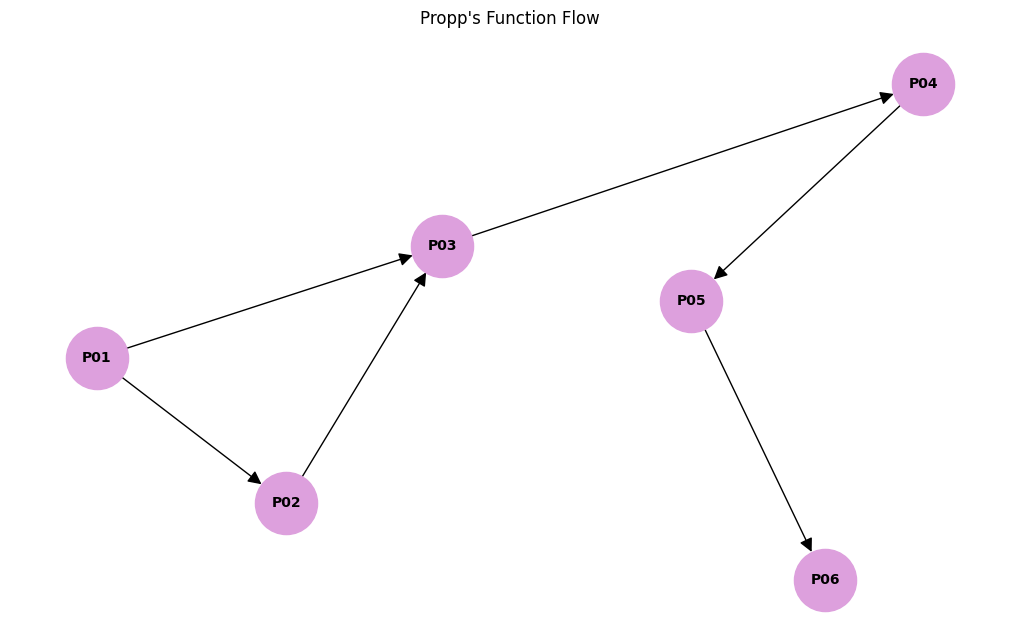

In [ ]:
def visualize_theory_structure(data_list, title="Theory Structure"):
    G = nx.DiGraph()

    for item in data_list:
        node_id = item['id']
        G.add_node(node_id, label=item['name'])

        for next_id in item.get('allowed_next', []):
            G.add_edge(node_id, next_id)

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, k=1.0) # k: 노드 간 거리 조절

    nx.draw(G, pos, with_labels=True, node_color='plum',
            node_size=2000, font_size=10, font_weight='bold',
            arrows=True, arrowsize=20)

    plt.title(title)
    plt.show()

# 프롭의 구조 시각화 예시 (상위 5개 데이터 기반 전이 구조)
visualize_theory_structure(theory_data['propp_functions'], "Propp's Function Flow")